In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

In [7]:
X, y = make_blobs(n_samples = 1000, centers = 3, n_features=2)

In [8]:
X

array([[-2.42775027,  8.92957803],
       [-2.21426346,  3.51636717],
       [-1.27516328,  7.96685093],
       ...,
       [-4.15652135,  8.25591796],
       [-4.53644878,  0.53178325],
       [ 0.53020581,  1.10954112]], shape=(1000, 2))

In [ ]:
y
## we can see the outputs are 0,1,2 means 3 clusters may be present.

array([0, 0, 0, 2, 2, 1, 0, 1, 1, 1, 0, 1, 0, 2, 2, 2, 1, 0, 0, 2, 0, 1,
       2, 1, 2, 2, 2, 0, 1, 1, 1, 1, 0, 1, 2, 0, 2, 0, 2, 1, 1, 2, 2, 0,
       0, 1, 2, 1, 0, 0, 1, 0, 2, 2, 1, 1, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       0, 2, 0, 0, 2, 1, 2, 1, 1, 0, 2, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 2, 2, 1, 1, 0, 2, 0, 2, 1, 0, 0, 0, 1, 2, 0, 1, 1, 1, 2, 1,
       2, 2, 2, 1, 0, 2, 0, 0, 1, 2, 0, 2, 0, 1, 0, 2, 0, 1, 2, 2, 1, 0,
       1, 0, 2, 2, 0, 2, 2, 2, 1, 1, 2, 2, 0, 1, 2, 1, 2, 2, 2, 1, 0, 2,
       0, 1, 1, 0, 0, 2, 2, 2, 0, 1, 1, 2, 1, 2, 2, 0, 1, 1, 1, 2, 1, 2,
       1, 2, 1, 0, 0, 2, 2, 1, 2, 2, 1, 2, 1, 0, 2, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 2, 1, 0, 1, 0, 1, 1, 2, 1, 0, 0, 2, 2, 1, 1, 2, 2, 1, 0, 1,
       0, 0, 1, 2, 1, 1, 0, 1, 2, 2, 1, 0, 2, 0, 2, 1, 1, 0, 2, 2, 0, 1,
       1, 0, 1, 1, 2, 0, 1, 0, 0, 2, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 2, 2,
       1, 1, 2, 2, 2, 0, 0, 1, 0, 1, 1, 2, 0, 0, 1, 1, 0, 2, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 2, 2, 0, 1, 2, 2, 0, 1, 1,

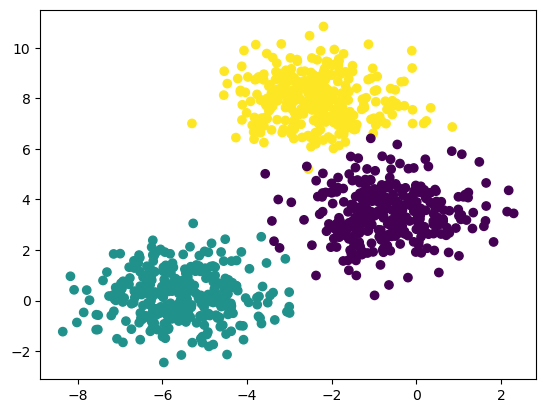

In [9]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.23, random_state=42)

In [18]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.cluster import KMeans

In [23]:
## Elbow method to select k value.
wcss = []
for k in range(1, 11):
    Kmeans = KMeans(n_clusters = k, init="k-means++")
    Kmeans.fit(X_train_scaled)
    wcss.append(Kmeans.inertia_) ## appending wcss value to the wcss list in each iteration f k value.

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [24]:
wcss

[1539.9999999999984,
 528.3646768224063,
 203.28547392492757,
 172.18059629735095,
 159.4906859635352,
 113.3724633925952,
 104.98336453120304,
 95.22751605623904,
 88.20146301482252,
 78.1069217575205]

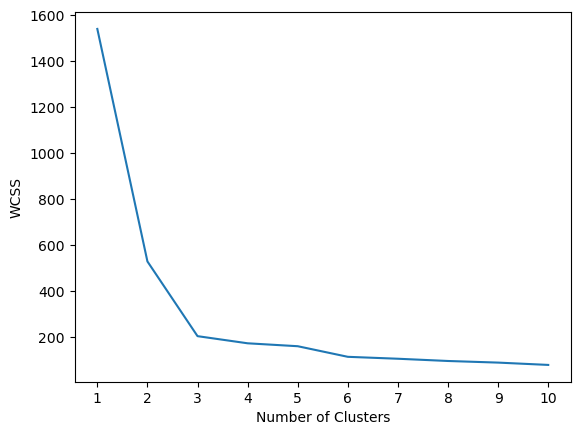

In [ ]:
## now plot k vs wcss to understand which value of K to choose
## Elbow curve
plt.plot(range(1,11), wcss)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## from the below graph  we can see that ...we need to choose k=3 according to the elbow method.

In [34]:
## now selectig k = 3 and  training the model.
Kmeans = KMeans(n_clusters=3, init="k-means++")

In [35]:
Kmeans.fit_predict(X_train_scaled)

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


array([1, 2, 2, 2, 0, 2, 2, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 2,
       0, 0, 1, 0, 1, 1, 2, 2, 2, 0, 1, 2, 1, 2, 0, 0, 1, 1, 0, 2, 0, 1,
       0, 2, 0, 2, 0, 1, 0, 2, 1, 1, 1, 0, 0, 0, 1, 2, 0, 0, 1, 1, 1, 1,
       1, 2, 0, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 0, 2, 1, 2, 0, 2, 0, 2,
       2, 0, 0, 2, 1, 2, 0, 0, 1, 2, 0, 1, 0, 1, 1, 1, 2, 0, 1, 1, 2, 2,
       0, 0, 2, 0, 2, 0, 2, 0, 1, 1, 1, 2, 0, 2, 0, 1, 1, 0, 1, 0, 2, 1,
       1, 0, 0, 0, 0, 2, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 2, 2, 2,
       0, 2, 0, 1, 1, 1, 0, 2, 1, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 0, 1,
       1, 2, 0, 1, 2, 2, 0, 1, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0,
       0, 2, 0, 0, 2, 2, 2, 0, 0, 2, 1, 1, 0, 1, 0, 1, 1, 2, 0, 1, 2, 0,
       2, 1, 0, 2, 2, 0, 1, 1, 2, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 2, 0, 2,
       1, 1, 1, 2, 0, 0, 2, 0, 2, 2, 1, 1, 0, 2, 1, 1, 0, 2, 2, 1, 2, 0,
       2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 0, 0, 0, 1, 0, 2, 1, 2, 2, 0, 0,
       1, 0, 2, 1, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2,

In [37]:
y_pred=Kmeans.predict(X_test_scaled)

In [38]:
y_pred

array([0, 1, 0, 2, 0, 2, 2, 0, 2, 2, 1, 1, 1, 0, 2, 2, 2, 1, 2, 1, 0, 0,
       2, 1, 1, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 1, 2, 1,
       2, 0, 2, 0, 1, 1, 0, 1, 1, 0, 0, 2, 0, 2, 1, 0, 0, 1, 2, 0, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 1, 2, 0, 1, 1, 0, 0, 0, 0, 1, 2,
       0, 2, 0, 0, 2, 0, 1, 2, 2, 1, 2, 0, 0, 2, 1, 2, 1, 2, 1, 0, 0, 0,
       2, 2, 1, 1, 2, 2, 1, 1, 1, 0, 2, 1, 1, 2, 1, 1, 2, 1, 2, 0, 1, 1,
       2, 2, 1, 0, 2, 0, 2, 2, 1, 2, 1, 1, 2, 2, 1, 0, 1, 2, 0, 0, 0, 2,
       2, 1, 1, 1, 2, 0, 0, 1, 1, 2, 1, 0, 2, 2, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 2, 0, 0, 1, 1, 0, 2, 1, 2, 1, 2, 1, 0, 0, 2, 1, 0, 2,
       0, 2, 1, 1, 0, 0, 2, 1, 1, 1, 2, 1, 0, 0, 2, 1, 1, 1, 2, 1, 0, 2,
       0, 1, 0, 1, 1, 2, 1, 2, 2, 0], dtype=int32)

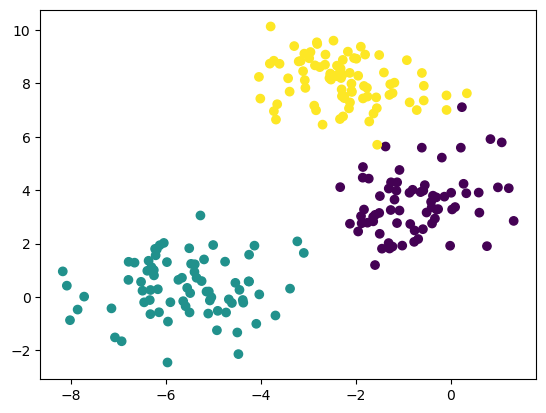

In [39]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [40]:
## Validating the k value
## 1) kneelocator
## 2) Silhoutee scoring

In [41]:
## kneelocator
!pip install kneed

In [42]:
from kneed import KneeLocator

In [43]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [ ]:
print(kl.elbow)
## from below we can see thet we have correctly predicted the k value. i.e 3

3


In [46]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [47]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [48]:
silhouette_coefficients

[0.6103174987917698,
 0.6471314792097187,
 0.5333819661657045,
 0.4784731626190305,
 0.42785003421662476,
 0.3650320463805443,
 0.3507994204727154,
 0.35342246797289106,
 0.3321841751211458]

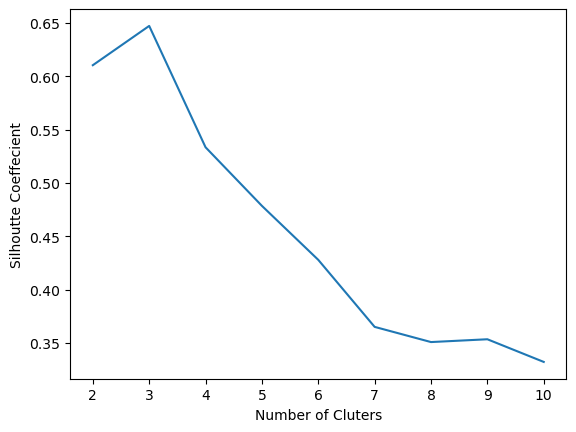

In [ ]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()

## from the below grpah we can see that the ...the Silhoutte coefficient is higest at k=3..
# so we have to choose K=3.